# Week 5 Day 3 Lab

In [23]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [9]:
def f(x):
    return x**2 + 6*x + 10
def df(x):
    return 2*x + 6
def gradient_descent(x0, epsilon=0.1, iterations=1000):
    x = x0
    for i in range(iterations):
        derivative = df(x)
        if derivative >0:
            x = x - epsilon
        elif derivative <0:
            x = x + epsilon
        else:
            break
    return x
minimum = gradient_descent(5)
print("Approximate minimum:", minimum)
print("Function value:", f(minimum))

Approximate minimum: -3.0000000000000004
Function value: 1.0


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [13]:
def func(x):
    return x[0]**2 + 6*x[0] + 10

In [16]:
%timeit gradient_descent(5)

170 μs ± 22.4 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [17]:
%timeit minimize(func, [5])

925 μs ± 23.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [18]:
starts = [-10, -5, 0, 5, 10]
for s in starts:
    print("Start =", s)
    print("Gradient descent:", gradient_descent(s))
    print("Scipy:", minimize(func, [s]).x[0])
    print()

Start = -10
Gradient descent: -3.0000000000000204
Scipy: -3.000000636935424

Start = -5
Gradient descent: -3.0000000000000027
Scipy: -2.9999999811153604

Start = 0
Gradient descent: -3.0000000000000013
Scipy: -3.0000000283269603

Start = 5
Gradient descent: -3.0000000000000004
Scipy: -2.9999995652413576

Start = 10
Gradient descent: -2.9999999999999827
Scipy: -2.999999508999382



### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [20]:
x = np.arange(20)
y = 2*x + 5 + np.random.normal(0, 2, 20)
def loss(params):
    m, b = params
    prediction = m*x + b
    return np.sum((y - prediction)**2)

In [21]:
%timeit minimize(loss, [0,0])

1.85 ms ± 39 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [22]:
%timeit np.polyfit(x, y, 1)

59.8 μs ± 1.71 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

In [24]:
def loss_2(params):
    m, b = params
    prediction = m*x + b
    return np.sum(np.abs(y - prediction))

In [26]:
sse_result = minimize(loss, [0,0])
mae_result = minimize(loss_2, [0,0])
m1, b1 = sse_result.x
m2, b2 = mae_result.x

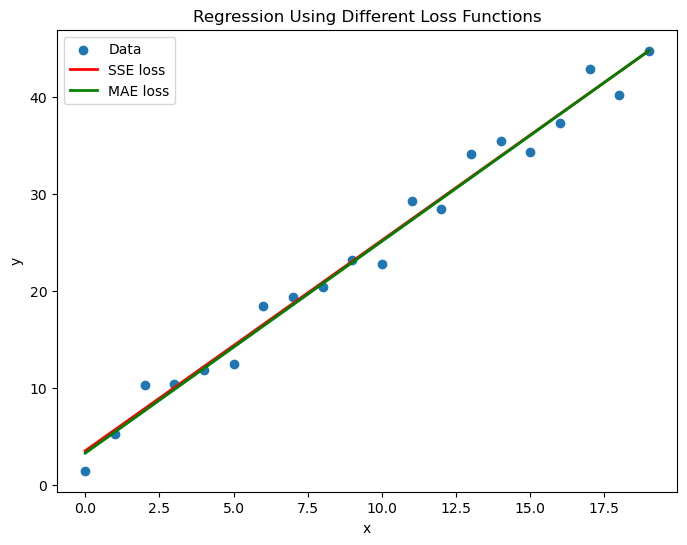

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, label="Data")
plt.plot(x, 
         m1*x + b1,
         color="red",
         linewidth=2,
         label = "SSE loss")
plt.plot(x, 
         m2*x + b2,
         color="green",
         linewidth=2,
         label = "MAE loss")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression Using Different Loss Functions")
plt.legend()
plt.show()